# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [28]:
# Importar librerías
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [29]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [30]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad` - Tipo float64, rango apropiado para edades
- `nivel_ingreso` - Tipo float64, valores positivos consistentes
- `visitas_mes` - Tipo int64, valores enteros apropiados
- `compras_mes` - Tipo int64, valores enteros apropiados
- `gasto_publicidad_dirigida` - Tipo float64, incluye valores 0.00
- `satisfaccion` - Tipo float64, escala 1-5 apropiada
- `ingreso_anual` - Tipo float64, variable objetivo
- 

La mayoría de estas variables presentan tipos de datos adecuados.  
Todas las columnas numéricas tienen tipos apropiados para el análisis correlacional.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [31]:
# Corregir el tipo de dato
# Después del análisis, todas las columnas tienen tipos de datos apropiados
# No se requieren correcciones de tipo de dato
print("Verificación completada: Todos los tipos de datos son apropiados para el análisis")

Verificación completada: Todos los tipos de datos son apropiados para el análisis


In [32]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [33]:
# Estadísticas descriptivas de variables numéricas
variables_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
                      'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

print("=== ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS ===")
estadisticas = df[variables_numericas].describe()
print(estadisticas)

=== ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS ===
               edad  nivel_ingreso   visitas_mes   compras_mes  \
count  15000.000000   15000.000000  15000.000000  15000.000000   
mean      38.262400   30019.704782     10.029000      1.206467   
std       11.492378    9833.166305      3.158189      1.105284   
min       18.000000    8000.000000      1.000000      0.000000   
25%       30.000000   23127.097500      8.000000      0.000000   
50%       38.000000   30023.745000     10.000000      1.000000   
75%       46.000000   36768.440000     12.000000      2.000000   
max       75.000000   74790.840000     25.000000      8.000000   

       gasto_publicidad_dirigida  satisfaccion  ingreso_anual  
count               15000.000000  15000.000000   15000.000000  
mean                   20.149301      3.603693      36.594180  
std                    10.880724      0.685300      34.484888  
min                     0.000000      1.000000       0.000000  
25%                    12.310

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — Distribución normal (media=38.3, mediana=38), rango apropiado 18-75 años
- `nivel_ingreso` — Distribución simétrica (media≈mediana≈30k), sin valores extremos
- `visitas_mes` — Distribución ligeramente sesgada, mayoría entre 8-12 visitas
- `compras_mes` — Altamente sesgada hacia la derecha, 75% hace ≤2 compras/mes
- `gasto_publicidad_dirigida` — Distribución amplia (0-75), muchos con gasto bajo
- `satisfaccion` — Distribución centrada en 3.6, escala 1-5 bien utilizada
- `ingreso_anual` — Variable objetivo con alta variabilidad (0-244), 25% sin ingresos 
- 

#### Explorar variables binarias

In [34]:
# Verificar que cada columna tenga únicamente dos valores posibles
variables_binarias = ['miembro_premium', 'abandono']

for columna in variables_binarias:
    print(f'\n=== {columna} ===')
    print('Valores únicos:')
    print(df[columna].unique())
    
    print('\nConteo de valores:')
    print(df[columna].value_counts())


=== miembro_premium ===
Valores únicos:
[0 1]

Conteo de valores:
0    12911
1     2089
Name: miembro_premium, dtype: int64

=== abandono ===
Valores únicos:
[0 1]

Conteo de valores:
0    12739
1     2261
Name: abandono, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- miembro_premium —
La mayoría de los clientes no cuenta con membresía premium, ya que únicamente 2,089 de los 15,000 usuarios pertenecen a este segmento.

abandono —
La mayor parte de los clientes permanece activa en la plataforma, mientras que 2,261 usuarios presentan abandono. 

#### Explorar variables categóricas

In [35]:
# Verificar el número de valores únicos por variable categórica

variables_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']

for columna in variables_categoricas:
    print(f'\n=== {columna} ===')
    
    print('Número de valores únicos:')
    print(df[columna].nunique())
    
    print('\nValores únicos:')
    print(df[columna].unique())


=== id_cliente ===
Número de valores únicos:
15000

Valores únicos:
['CL-100000' 'CL-100001' 'CL-100002' ... 'CL-114997' 'CL-114998'
 'CL-114999']

=== tipo_dispositivo ===
Número de valores únicos:
3

Valores únicos:
['móvil' 'tablet' 'escritorio']

=== region ===
Número de valores únicos:
4

Valores únicos:
['norte' 'sur' 'este' 'oeste']


In [36]:
# Explorar variables categóricas y cómo se distribuyen
variables_categoricas = ['tipo_dispositivo', 'region']

for columna in variables_categoricas:
    print(f'\n=== Distribución de {columna} ===')
    print(df[columna].value_counts())


=== Distribución de tipo_dispositivo ===
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

=== Distribución de region ===
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- tipo_dispositivo —
La mayoría de los clientes utiliza dispositivos móviles, mientras que tablet representa la categoría menos frecuente.

- region —
La distribución por región es relativamente equilibrada, aunque la región norte concentra la mayor cantidad de clientes.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

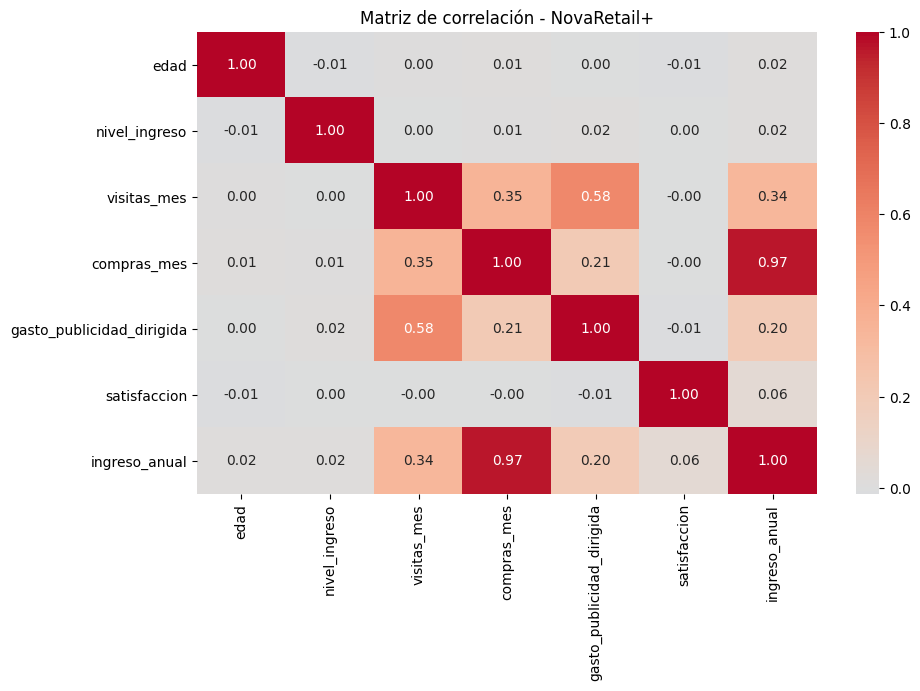

In [37]:
# Visualizar la matriz de correlación para identificar relaciones
variables_numericas = [
    'edad',
    'nivel_ingreso',
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'satisfaccion',
    'ingreso_anual'
]

# Matriz de correlación
matriz_corr = df[variables_numericas].corr()

# Configuración de la gráfica
plt.figure(figsize=(10, 6))

# Heatmap
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    center=0
)

plt.title('Matriz de correlación - NovaRetail+')
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observan correlaciones positivas entre varias variables de comportamiento del cliente. 
La relación más fuerte aparece entre compras_mes e ingreso_anual, lo que indica que los clientes que realizan más compras generan mayores ingresos para la empresa.

También destaca una correlación moderada entre visitas_mes y gasto_publicidad_dirigida, sugiriendo que los usuarios con mayor exposición publicitaria tienden a visitar más la plataforma.

Variables como edad, nivel_ingreso y satisfaccion presentan correlaciones muy bajas con el resto de variables.


Observaciones respecto a `ingreso_anual`  
- ingreso_anual presenta una correlación muy fuerte y positiva con compras_mes (0.97), siendo la relación más importante del análisis.

También muestra correlaciones positivas moderadas con visitas_mes (0.34) y gasto_publicidad_dirigida (0.20), lo que podría indicar que una mayor interacción y exposición publicitaria se relacionan con mayores ingresos generados.

La satisfacción, edad y nivel_ingreso muestran relaciones débiles con ingreso_anual, por lo que aparentemente tienen menor impacto directo dentro de este análisis correlacional.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

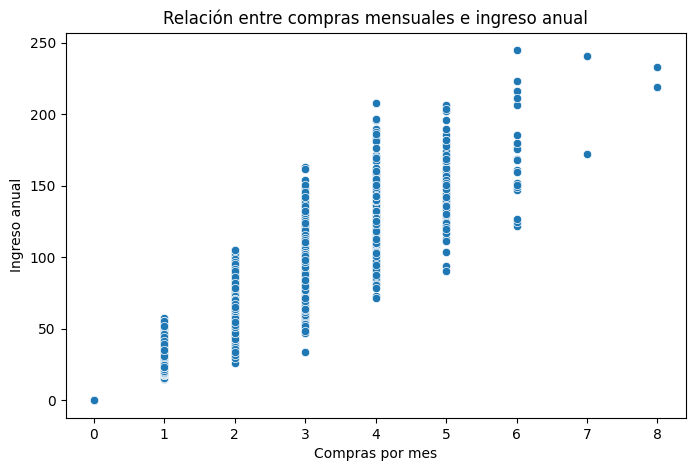

In [38]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual'
)

plt.title('Relación entre compras mensuales e ingreso anual')
plt.xlabel('Compras por mes')
plt.ylabel('Ingreso anual')

plt.show()

### Scatterplot para pares clave

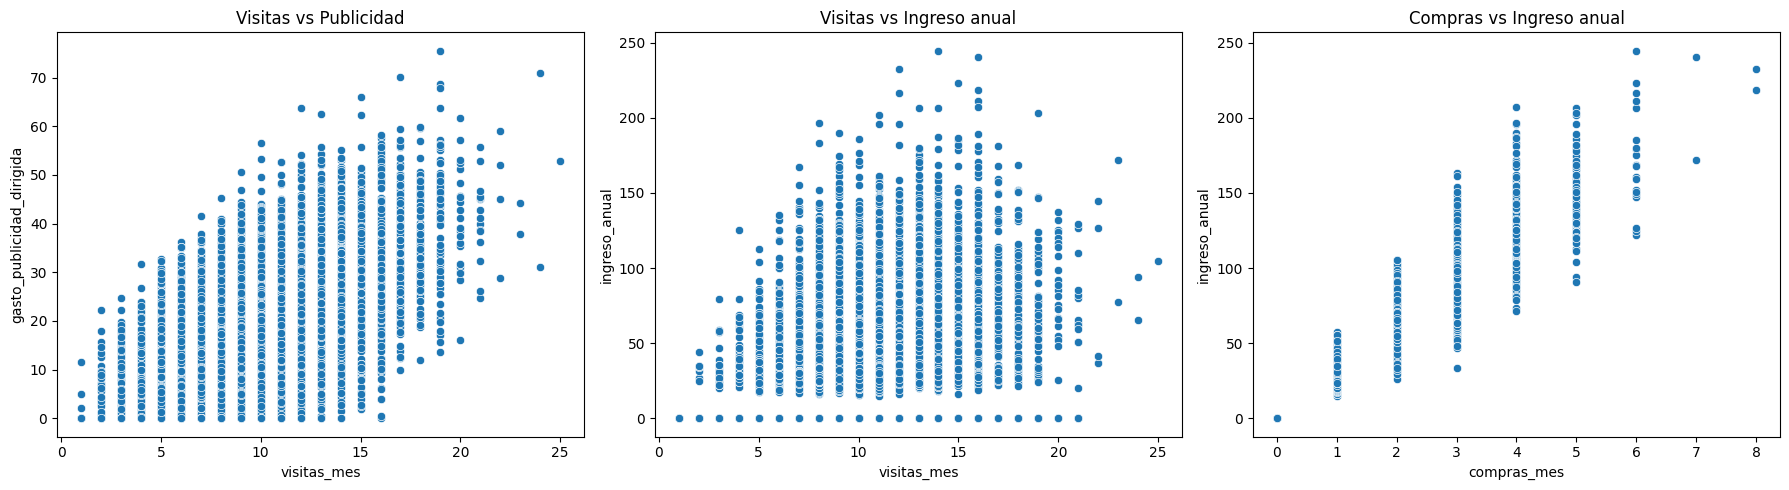

In [39]:
# Visualizar pares de variables con relaciones moderadas o fuertes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# visitas vs publicidad
sns.scatterplot(
    data=df,
    x='visitas_mes',
    y='gasto_publicidad_dirigida',
    ax=axes[0]
)

axes[0].set_title('Visitas vs Publicidad')

# visitas vs ingreso anual
sns.scatterplot(
    data=df,
    x='visitas_mes',
    y='ingreso_anual',
    ax=axes[1]
)

axes[1].set_title('Visitas vs Ingreso anual')

# compras vs ingreso anual
sns.scatterplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual',
    ax=axes[2]
)

axes[2].set_title('Compras vs Ingreso anual')

plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**visitas_mes vs gasto_publicidad_dirigida**

Dirección positiva moderada. A medida que aumenta el gasto en publicidad dirigida, también tiende a incrementarse el número de visitas mensuales. La dispersión es media y no se observan outliers extremos relevantes.

**visitas_mes vs ingreso_anual**

Dirección positiva moderada. Los clientes con más visitas suelen generar mayores ingresos anuales, aunque existe una dispersión considerable entre los datos. No se identifican patrones de colinealidad fuerte.

**compras_mes vs ingreso_anual**

Dirección positiva fuerte. Conforme aumenta el número de compras mensuales, el ingreso anual también incrementa de manera clara y consistente. La dispersión es baja en comparación con los otros pares, lo que sugiere una posible colinealidad fuerte entre ambas variables. No se observan outliers extremos importantes.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [40]:
# Calcular correlación entre variables relevantes
pearson_1 = df['compras_mes'].corr(df['ingreso_anual'], method='pearson')
pearson_2 = df['visitas_mes'].corr(df['ingreso_anual'], method='pearson')
pearson_3 = df['visitas_mes'].corr(df['gasto_publicidad_dirigida'], method='pearson')

print('=== Correlación de Pearson ===')

print(f'compras_mes vs ingreso_anual: {pearson_1:.2f}')
print(f'visitas_mes vs ingreso_anual: {pearson_2:.2f}')
print(f'visitas_mes vs gasto_publicidad_dirigida: {pearson_3:.2f}')

=== Correlación de Pearson ===
compras_mes vs ingreso_anual: 0.97
visitas_mes vs ingreso_anual: 0.34
visitas_mes vs gasto_publicidad_dirigida: 0.58


In [41]:
# Calcular correlación entre variables relevantes
spearman_1 = df['compras_mes'].corr(df['ingreso_anual'], method='spearman')
spearman_2 = df['visitas_mes'].corr(df['ingreso_anual'], method='spearman')
spearman_3 = df['visitas_mes'].corr(df['gasto_publicidad_dirigida'], method='spearman')

print('=== Correlación de Spearman ===')

print(f'compras_mes vs ingreso_anual: {spearman_1:.2f}')
print(f'visitas_mes vs ingreso_anual: {spearman_2:.2f}')
print(f'visitas_mes vs gasto_publicidad_dirigida: {spearman_3:.2f}')

=== Correlación de Spearman ===
compras_mes vs ingreso_anual: 0.97
visitas_mes vs ingreso_anual: 0.32
visitas_mes vs gasto_publicidad_dirigida: 0.56


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**compras_mes vs ingreso_anual**

Correlación positiva muy fuerte tanto en Pearson (0.97) como en Spearman (0.97). Esto indica una asociación directa y consistente entre la cantidad de compras y el ingreso anual generado.

**visitas_mes vs ingreso_anual**

Correlación positiva moderada en Pearson (0.34) y Spearman (0.32). Un mayor número de visitas parece relacionarse con mayores ingresos, aunque la relación presenta mayor dispersión.

**visitas_mes vs gasto_publicidad_dirigida**

Correlación positiva moderada en Pearson (0.58) y Spearman (0.56). Esto sugiere que una mayor inversión publicitaria puede asociarse con un incremento en las visitas mensuales.

### Punto-biserial

In [42]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

print("Valores únicos en miembro_premium:", df['miembro_premium'].unique())
print("Valores únicos en abandono:", df['abandono'].unique())
print()  

corr_premium, _ = pointbiserialr(
    df['miembro_premium'],
    df['ingreso_anual']
)

corr_abandono, _ = pointbiserialr(
    df['abandono'],
    df['ingreso_anual']
)

print('=== Correlación Punto-Biserial ===')
print(f'miembro_premium vs ingreso_anual: {corr_premium:.2f}')
print(f'abandono vs ingreso_anual: {corr_abandono:.2f}')

Valores únicos en miembro_premium: [0 1]
Valores únicos en abandono: [0 1]

=== Correlación Punto-Biserial ===
miembro_premium vs ingreso_anual: 0.09
abandono vs ingreso_anual: -0.00


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**

Relación positiva débil (0.09). Los clientes con membresía premium tienden a generar ligeramente más ingresos, aunque la asociación es baja.

**abandono vs ingreso_anual**

Relación prácticamente nula y ligeramente negativa (-0.00). No se observa una asociación relevante entre el abandono de clientes y el ingreso anual generado dentro de este análisis.

### V de Cramér

In [43]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(tabla):
    
    chi2 = chi2_contingency(tabla)[0]
    
    n = tabla.sum().sum()
    
    min_dim = min(tabla.shape) - 1
    
    return np.sqrt(chi2 / (n * min_dim))

In [44]:
# Aplicar V de Cramér en variables relevantes
tabla_cruzada = pd.crosstab(
    df['tipo_dispositivo'],
    df['region']
)

v_cramer = cramers_v(tabla_cruzada)

print('=== V de Cramér ===')
print(f'tipo_dispositivo vs region: {v_cramer:.2f}')


=== V de Cramér ===
tipo_dispositivo vs region: 0.01


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

**tipo_dispositivo vs region**

La asociación entre tipo_dispositivo y region es extremadamente débil (0.01), lo que indica que prácticamente no existe relación entre ambas variables categóricas dentro del dataset.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio


### Hallazgo 1 — 

**Evidencia visual:**
El heatmap y los scatterplots muestran una relación positiva clara entre compras_mes e ingreso_anual, con una dispersión baja y una tendencia ascendente consistente.

**Evidencia numérica:**
La correlación entre compras_mes e ingreso_anual fue de 0.97 tanto en Pearson como en Spearman, representando la relación más fuerte del análisis.

**Interpretación**
Los clientes que realizan más compras mensuales tienden a generar mayores ingresos anuales para la empresa. La relación observada es fuerte y consistente dentro del dataset analizado.

**No podemos afirmar**
No se puede concluir que incrementar artificialmente la cantidad de compras cause directamente un aumento en el ingreso anual, ya que el análisis realizado es correlacional y no causal.

**Implicación de negocio**
NovaRetail+ podría enfocar estrategias de retención, promociones y programas de fidelización en incentivar compras recurrentes, debido a la fuerte asociación observada con el ingreso generado.


### Hallazgo 2 — 

**Evidencia visual:**
Los scatterplots muestran una relación positiva moderada entre visitas_mes e ingreso_anual, así como entre visitas_mes y gasto_publicidad_dirigida, aunque con mayor dispersión entre los datos.

**Evidencia numérica:**
La correlación entre visitas_mes e ingreso_anual fue de 0.34 en Pearson y 0.32 en Spearman.

La relación entre visitas_mes y gasto_publicidad_dirigida fue de 0.58 en Pearson y 0.56 en Spearman.

**Interpretación**
Los clientes con mayor actividad en la plataforma tienden a generar más ingresos, y una mayor exposición publicitaria parece asociarse con un incremento en las visitas mensuales.

**No podemos afirmar**
No se puede asegurar que aumentar el gasto publicitario provoque directamente mayores ingresos o visitas, ya que podrían intervenir otros factores no observados en el análisis.

**Implicación de negocio**
La empresa podría evaluar campañas orientadas a incrementar la interacción de los usuarios con la plataforma, monitoreando posteriormente si estas acciones generan mejoras sostenibles en ingresos y retención.

Hallazgo 3 —

**Evidencia visual:**
Las variables binarias no mostraron patrones visuales fuertes respecto al ingreso_anual dentro de las visualizaciones generales.

**Evidencia numérica:**
La correlación punto-biserial entre miembro_premium e ingreso_anual fue de 0.09, mientras que abandono e ingreso_anual presentó una relación prácticamente nula (-0.00).

**Interpretación**
La membresía premium presenta una asociación positiva débil con el ingreso anual, mientras que el abandono no parece relacionarse significativamente con los ingresos generados dentro de este conjunto de datos.

**No podemos afirmar**
No se puede concluir que adquirir una membresía premium aumente directamente los ingresos generados por un cliente, ni que el abandono afecte automáticamente el ingreso anual.

**Implicación de negocio**
La empresa podría analizar con mayor profundidad el comportamiento de los usuarios premium para identificar si existen segmentos específicos donde la membresía tenga mayor impacto económico.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Este análisis es únicamente correlacional, por lo que no se puede afirmar que una variable cause cambios directos en otra.
- También es posible que existan factores no incluidos en el dataset que influyan en los resultados, como promociones, temporadas de ventas o comportamiento histórico de los clientes.
- Además, algunas variables mostraron relaciones débiles con ingreso_anual, por lo que el análisis no explica completamente todos los factores asociados al ingreso generado.

### **Próximos pasos** 

Probar segmentación adicional
- Comparar el comportamiento entre clientes premium y no premium.
- Analizar diferencias entre regiones y tipos de dispositivo.

Realizar análisis predictivo
- Crear modelos que permitan estimar el ingreso_anual.
- Identificar cuáles variables tienen mayor peso en la predicción.
  
Paso 3 — Profundizar en el comportamiento del cliente
- Incorporar más variables relacionadas con actividad histórica.
- Analizar por separado a los clientes con ingreso_anual igual a cero.